# 손바닥 sEMG 데이터 탐색 및 파형 비교
**딥러닝프로그래밍 · 1주차 실습 보고서**

공개 손바닥 표면근전도(sEMG) 데이터의 구조를 점검하고, 피험자별 파형과 선행연구를 비교한다.
등록된 사람 가운데 누구인지 구분하는 **사용자 식별**을 준비하는 단계이며, 이번 실습에서는 분류 모델을 학습하지 않는다.

- **대상:** A–E 5명, 1인당 50회, 전체 250회
- **검사 결과:** 모든 파일은 (3000, 2)이며 유한값으로 구성된다. 내용이 같은 파일 한 쌍이 있어 고유한 파일 내용은 249개이다.
- **파형 비교:** 각 피험자의 파일명상 1번 시행을 선택한 5개 파일
- **제출 저장소:** https://github.com/KyunghoCha/semg-auth-coursework
- **작성 기준:** 강의자료 14·17쪽, 원논문 Table 1·3, 공개 데이터 README

## 1. 환경 확인
WSL의 Anaconda semg 환경에서 아래 명령을 실제 실행한다. 출력에는 Python 경로, 패키지 버전,
GPU 인식 여부와 간단한 GPU 연산 결과가 포함된다. 학습 성능이나 학습 메모리 사용량을 검증하는 실험은 아니다.

In [1]:
from pathlib import Path
import sys, json, subprocess, platform, hashlib, re
from datetime import datetime
from zoneinfo import ZoneInfo
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data" / "data" / "A").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("README의 명령으로 공개 데이터를 프로젝트의 data 폴더에 받으세요.")
OUT = ROOT / "submission"
IMAGES = OUT / "images"
IMAGES.mkdir(parents=True, exist_ok=True)
RUN_AT = datetime.now(ZoneInfo("Asia/Seoul")).isoformat(timespec="seconds")
REPO_URL = "https://github.com/KyunghoCha/semg-auth-coursework"
font_names = {f.name for f in font_manager.fontManager.ttflist}
FONT = next((f for f in ["NanumGothic", "Malgun Gothic", "Noto Sans CJK JP"]
             if f in font_names), "DejaVu Sans")
plt.rcParams.update({"font.family": FONT, "axes.unicode_minus": False,
                     "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

check_code = """import sys, platform, numpy, scipy, pandas, sklearn, pywt, matplotlib, torch, torchvision
print("Python:", platform.python_version())
print("Interpreter:", sys.executable)
print("OS:", platform.system(), platform.release())
print("Imports: numpy, scipy, pandas, sklearn, pywt, matplotlib, torch, torchvision OK")
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("CUDA build:", torch.version.cuda, "| available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "CUDA unavailable"
print("GPU:", torch.cuda.get_device_name(0))
print("GPU operation:", (torch.ones(4, device="cuda") * 2).cpu().tolist())
"""
result = subprocess.run([sys.executable, "-c", check_code], text=True, capture_output=True, check=True)
environment_output = result.stdout.strip()
print(environment_output)
(OUT / "environment_check.txt").write_text(
    f"Executed at: {RUN_AT}\nCommand: semg Python subprocess\n\n" + environment_output + "\n",
    encoding="utf-8")
packages = {name: metadata.version(name) for name in
            ["numpy", "scipy", "pandas", "scikit-learn", "PyWavelets", "matplotlib",
             "torch", "torchvision", "ipykernel", "nbformat", "nbclient", "nbconvert"]}
environment = {"executed_at": RUN_AT, "python": platform.python_version(),
               "interpreter": sys.executable, "os": platform.platform(),
               "packages": packages, "stdout": environment_output}
(OUT / "environment.json").write_text(json.dumps(environment, ensure_ascii=False, indent=2), encoding="utf-8")
display(pd.DataFrame(packages.items(), columns=["패키지", "버전"]))

Python: 3.12.14
Interpreter: /home/ckh/anaconda3/envs/semg/bin/python
OS: Linux 6.6.87.2-microsoft-standard-WSL2
Imports: numpy, scipy, pandas, sklearn, pywt, matplotlib, torch, torchvision OK
PyTorch: 2.13.0+cu126 | torchvision: 0.28.0+cu126
CUDA build: 12.6 | available: True
GPU: NVIDIA GeForce RTX 3070 Laptop GPU
GPU operation: [2.0, 2.0, 2.0, 2.0]


,패키지,버전
0,numpy,2.5.2
1,scipy,1.18.0
2,pandas,3.0.5
3,scikit-learn,1.9.0
4,PyWavelets,1.9.0
5,matplotlib,3.11.0
6,torch,2.13.0+cu126
7,torchvision,0.28.0+cu126
8,ipykernel,7.3.0
9,nbformat,5.11.0


## 2. 데이터 구조 및 품질 점검
파일 하나가 한 피험자의 **1회 측정**이다. 1,000 Hz에서 3초를 기록했으므로 예상 크기는 **(3000, 2)**이다.
첫 줄의 열 이름을 제외하고 읽는다. 폴더 이름이 피험자 레이블이며, 정렬 목록의 위치와 피험자 번호를 구분한다.

공개 CSV에는 이미 **60 Hz 노치 필터와 20–500 Hz 대역통과 필터**가 적용되어 있다.
이번 탐색에서는 다시 필터링하거나 정규화하지 않고 저장된 값을 그대로 사용한다.
README에서 진폭의 물리 단위를 확정할 수 없어 **CSV 기록값 단위**를 사용한다.

In [2]:
DATA = ROOT / "data" / "data"
files = sorted(DATA.rglob("*.csv"))
records, signals = [], {}
for path in files:
    with path.open(encoding="utf-8-sig") as stream:
        header = stream.readline().strip()
    values = np.loadtxt(path, delimiter=",", skiprows=1)
    assert values.shape == (3000, 2), f"Unexpected shape: {path}: {values.shape}"
    assert np.isfinite(values).all(), f"NaN or infinity: {path}"
    assert header == "Comp Ch 3,Comp Ch 4", f"Unexpected header: {path}"
    trial = int(re.search(r"\((\d+)\)", path.stem).group(1))
    records.append({"subject": path.parent.name, "trial": trial,
                    "path": path.relative_to(ROOT).as_posix(), "rows": len(values), "channels": 2,
                    "minimum": float(values.min()), "maximum": float(values.max()),
                    "sha256": hashlib.sha256(path.read_bytes()).hexdigest()})
    signals[(path.parent.name, trial)] = values
manifest = pd.DataFrame(records).sort_values(["subject", "trial"]).reset_index(drop=True)
assert len(manifest) == 250 and set(manifest.subject) == set("ABCDE")
assert not manifest.duplicated(["subject", "trial"]).any()
for subject, group in manifest.groupby("subject"):
    assert set(group.trial) == set(range(1, 51)), subject
summary = (manifest.groupby("subject").agg(trials=("trial", "size"),
            minimum=("minimum", "min"), maximum=("maximum", "max")).reset_index())
summary["shape"], summary["duration_s"] = "(3000, 2)", 3.0
summary = summary[["subject", "trials", "shape", "duration_s", "minimum", "maximum"]]
manifest.to_csv(OUT / "data_manifest.csv", index=False)
summary.to_csv(OUT / "data_summary.csv", index=False)
display(summary.rename(columns={"subject":"피험자", "trials":"파일/시행 수",
 "shape":"파일별 배열 크기", "duration_s":"시행 시간(s)", "minimum":"최솟값", "maximum":"최댓값"}).round(5))
print(f"전체 {len(manifest)}개: 크기·유한값·헤더·시행 번호 검사 통과")
print("전체 시점 수:", int(manifest.rows.sum()),
      "/ 스칼라 값 수:", int((manifest.rows * manifest.channels).sum()))
print("파일 내용 SHA-256 중복 수:", int(manifest.sha256.duplicated().sum()))
data_commit = subprocess.run(["git", "-C", str(ROOT / "data"), "rev-parse", "HEAD"],
                             text=True, capture_output=True, check=True).stdout.strip()
print("데이터 저장소 커밋:", data_commit)
duplicate_rows = manifest[manifest.duplicated("sha256", keep=False)]
if not duplicate_rows.empty:
    display(duplicate_rows[["subject", "trial", "path"]])
    display(Markdown("**자료 점검 메모:** 위 파일들은 바이트 내용이 같다. 원자료는 수정하지 않았으며, 서로 다른 독립 시행인지 여부는 이 파일만으로 확인할 수 없다. 이후 학습·평가 분할 전에 중복의 원인을 확인해야 한다."))

,피험자,파일/시행 수,파일별 배열 크기,시행 시간(s),최솟값,최댓값
0,A,50,"(3000, 2)",3.0,-3.53656,4.33942
1,B,50,"(3000, 2)",3.0,-1.38533,1.67226
2,C,50,"(3000, 2)",3.0,-0.66399,0.74176
3,D,50,"(3000, 2)",3.0,-1.24915,1.27618
4,E,50,"(3000, 2)",3.0,-2.11037,2.01869


전체 250개: 크기·유한값·헤더·시행 번호 검사 통과
전체 시점 수: 750000 / 스칼라 값 수: 1500000
파일 내용 SHA-256 중복 수: 1
데이터 저장소 커밋: adb7955f4416165c88e4111af6f8fdafd416209c


,subject,trial,path
237,E,38,data/data/E/e (38).csv
249,E,50,data/data/E/e (50).csv


**자료 점검 메모:** 위 파일들은 바이트 내용이 같다. 원자료는 수정하지 않았으며, 서로 다른 독립 시행인지 여부는 이 파일만으로 확인할 수 없다. 이후 학습·평가 분할 전에 중복의 원인을 확인해야 한다.

## 3. 피험자별 파형
각 피험자의 **1번 시행**을 폴더·시행 번호로 선택한다. 현재 파일 목록의 인덱스 0·50·100·150·200과 대응하지만,
파일 정렬에 의존하지 않도록 (피험자, 시행)으로 선택한다.

- **채널 1:** APB, 짧은엄지벌림근 / CSV 열 Comp Ch 3
- **채널 2:** ADM, 새끼벌림근 / CSV 열 Comp Ch 4
- **구간:** 0≤t<1초 파지, 1≤t<2초 회전, 2≤t<3초 정지
- 경계는 실험 프로토콜의 시간 구분이며, 실제 동작 시작을 신호에서 검출한 결과는 아니다.
- 작은 파형도 읽을 수 있도록 패널별 y축을 자동 설정했다. 절대 진폭 비교는 눈금 및 RMS 표를 함께 본다.

In [3]:
FS = 1000
selected = {s: signals[(s, 1)] for s in "ABCDE"}
time = np.arange(3000) / FS
phase_labels = ["파지", "회전", "정지"]
phase_colors = ["#e8eef5", "#e6f3ee", "#f3eee7"]
def plot_subject(subject):
    values = selected[subject]
    fig, axes = plt.subplots(2, 1, figsize=(10, 4.7), sharex=True, constrained_layout=True)
    for ch, ax in enumerate(axes):
        for index, label in enumerate(phase_labels):
            ax.axvspan(index, index + 1, color=phase_colors[index], alpha=.65, zorder=0)
            ax.text(index + .5, .96, label, ha="center", va="top",
                    transform=ax.get_xaxis_transform(), fontsize=9, color="#334155")
        ax.plot(time, values[:, ch], color="#176e9c", lw=.65)
        ax.axvline(1, color="#64748b", ls="--", lw=.8)
        ax.axvline(2, color="#64748b", ls="--", lw=.8)
        ax.set_ylabel(f"채널 {ch + 1} ({['APB', 'ADM'][ch]})\n진폭 (CSV 기록값)")
        ax.grid(axis="y", alpha=.2)
        ax.set_xlim(0, 3)
        ax.margins(y=.25)
    axes[-1].set_xlabel("시간 (s)")
    fig.suptitle(f"피험자 {subject} · 1번 시행 · 손바닥 sEMG", fontsize=13, fontweight="bold")
    fig.savefig(IMAGES / f"subject_{subject}.png", dpi=160, facecolor="white")
    plt.show()
    plt.close(fig)

### 피험자 A

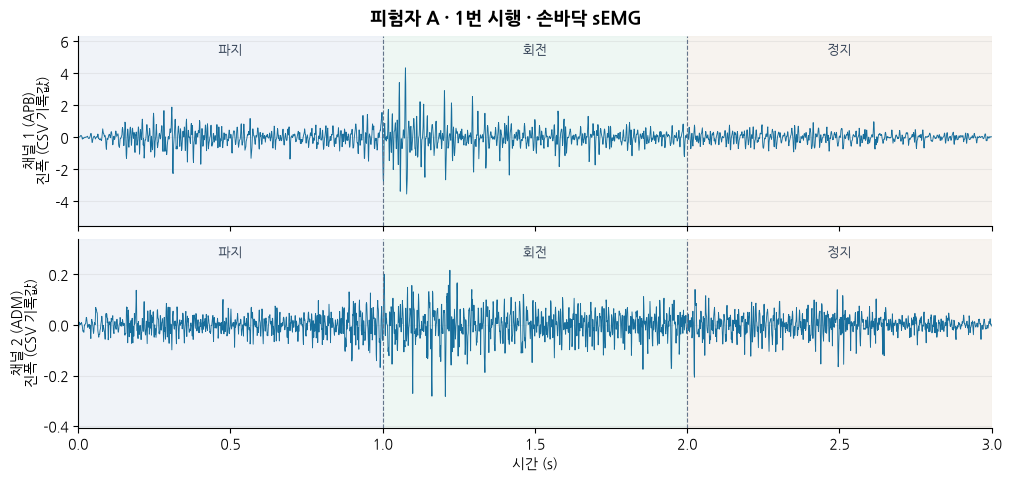

In [4]:
plot_subject("A")

### 피험자 B

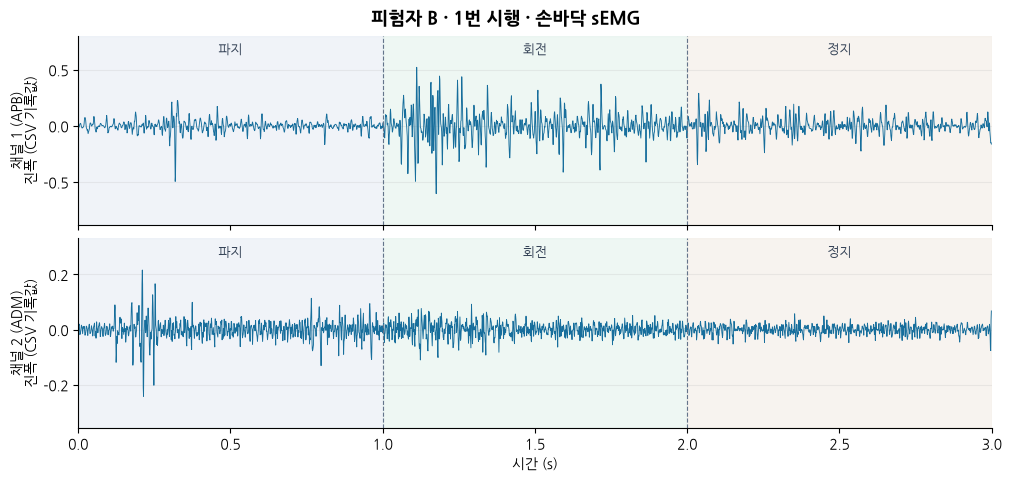

In [5]:
plot_subject("B")

### 피험자 C

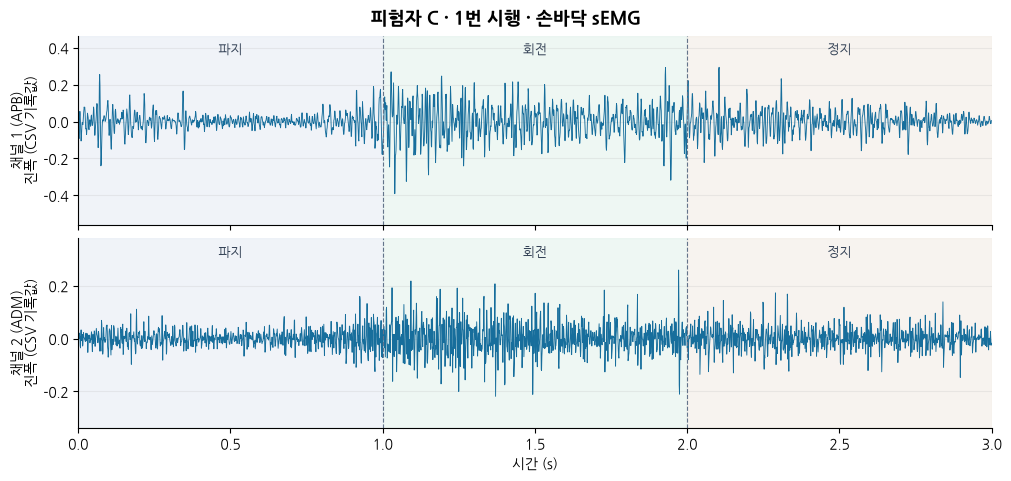

In [6]:
plot_subject("C")

### 피험자 D

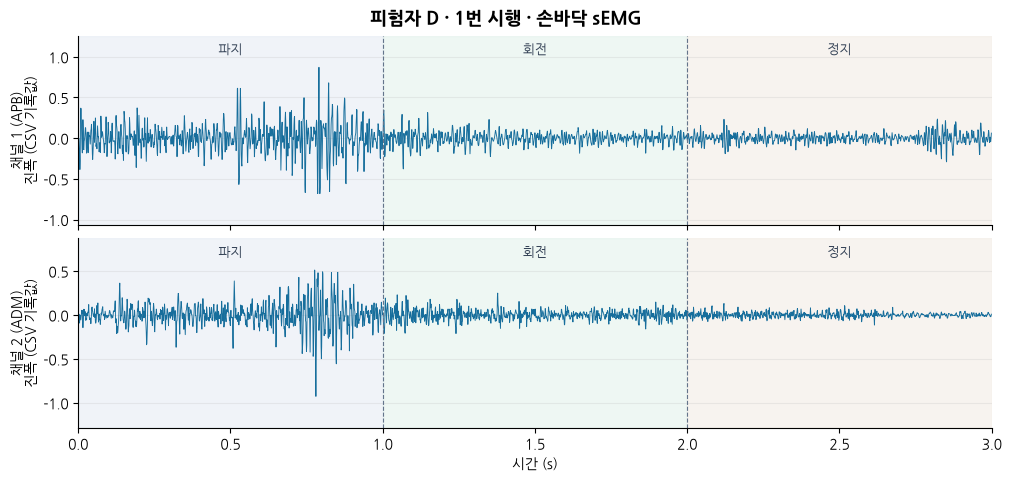

In [7]:
plot_subject("D")

### 피험자 E

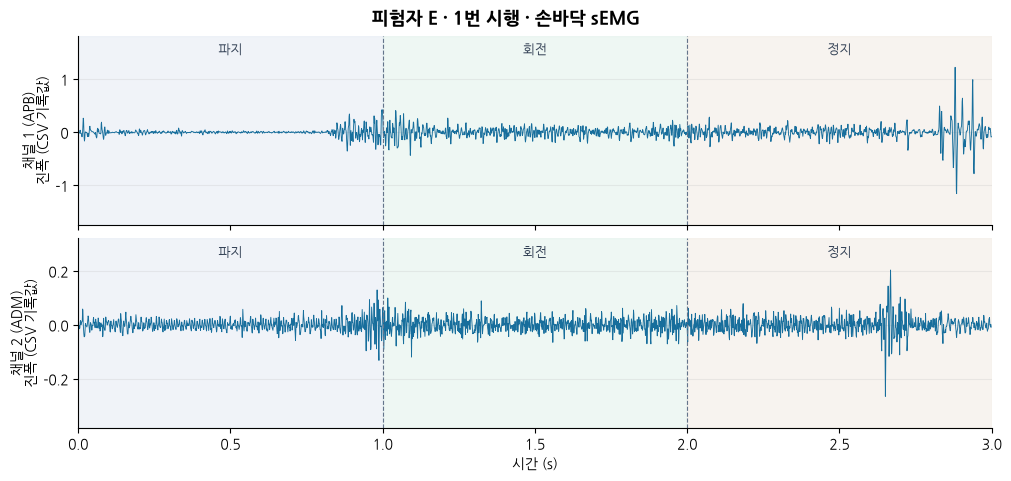

In [8]:
plot_subject("E")

## 4. 관찰 메모
아래 메모는 **각 피험자의 1번 시행, 총 5개 파일**에 한정한다. 50회 전체를 대표하는 특성이나 식별 정확도로 일반화하지 않는다.
진폭을 보조적으로 비교하기 위해 구간별 RMS(제곱평균제곱근)를 계산했다.
길이 N인 신호 x의 RMS는 sqrt(mean(x²))이며 단위는 원래 CSV 기록값과 같다.

In [9]:
rms_rows = []
for subject, values in selected.items():
    for channel in range(2):
        row = {"subject": subject, "channel": channel + 1}
        for i, phase in enumerate(["grasp", "rotate", "stop"]):
            row[phase] = float(np.sqrt(np.mean(values[i * FS:(i + 1) * FS, channel] ** 2)))
        rms_rows.append(row)
rms = pd.DataFrame(rms_rows)
rms.to_csv(OUT / "phase_rms.csv", index=False)
display(rms.rename(columns={"subject":"피험자", "channel":"채널",
 "grasp":"파지 RMS", "rotate":"회전 RMS", "stop":"정지 RMS"}).round(4))
def metric(subject, channel, phase):
    return float(rms.loc[(rms.subject == subject) & (rms.channel == channel), phase].iloc[0])
observations = [
 (f"A의 1번 시행에서 채널 1 RMS는 파지 {metric('A',1,'grasp'):.4f}, "
  f"회전 {metric('A',1,'rotate'):.4f}, 정지 {metric('A',1,'stop'):.4f}였다. "
  "이 시행에서는 회전 구간의 진폭이 가장 컸고, 그림에서도 1초 직후에 큰 변동이 보였다."),
 (f"D의 1번 시행에서 채널 1 RMS는 파지 {metric('D',1,'grasp'):.4f}, "
  f"회전 {metric('D',1,'rotate'):.4f}, 정지 {metric('D',1,'stop'):.4f}였다. "
  "D에서는 파지 구간이 가장 커서 A와 시간별 진폭 패턴이 달랐다. "
  "선택한 시행들에서 RMS가 가장 큰 동작 구간은 피험자마다 달랐다."),
 (f"A의 회전 구간 RMS는 채널 1 {metric('A',1,'rotate'):.4f}, "
  f"채널 2 {metric('A',2,'rotate'):.4f}로 약 "
  f"{metric('A',1,'rotate')/metric('A',2,'rotate'):.1f}배 차이가 났다. "
  f"C의 같은 구간에서는 채널 1 {metric('C',1,'rotate'):.4f}, "
  f"채널 2 {metric('C',2,'rotate'):.4f}였다. "
  "두 채널의 진폭 관계도 피험자에 따라 달랐다. 각 그림의 y축 눈금을 함께 확인해야 했다.")
]
assert metric("A",1,"rotate") > max(metric("A",1,"grasp"), metric("A",1,"stop"))
assert metric("D",1,"grasp") > max(metric("D",1,"rotate"), metric("D",1,"stop"))
display(Markdown("\n\n".join(f"**관찰 {i+1}.** {s}" for i,s in enumerate(observations))))

,피험자,채널,파지 RMS,회전 RMS,정지 RMS
0,A,1,0.4698,0.6932,0.2772
1,A,2,0.0364,0.0590,0.0384
2,B,1,0.0479,0.1199,0.0639
3,B,2,0.0345,0.0244,0.0158
4,C,1,0.0470,0.0897,0.0576
5,C,2,0.0303,0.0574,0.0380
6,D,1,0.1701,0.0720,0.0599
7,D,2,0.1351,0.0558,0.0273
8,E,1,0.0636,0.0897,0.1466
9,E,2,0.0210,0.0249,0.0295


**관찰 1.** A의 1번 시행에서 채널 1 RMS는 파지 0.4698, 회전 0.6932, 정지 0.2772였다. 이 시행에서는 회전 구간의 진폭이 가장 컸고, 그림에서도 1초 직후에 큰 변동이 보였다.

**관찰 2.** D의 1번 시행에서 채널 1 RMS는 파지 0.1701, 회전 0.0720, 정지 0.0599였다. D에서는 파지 구간이 가장 커서 A와 시간별 진폭 패턴이 달랐다. 선택한 시행들에서 RMS가 가장 큰 동작 구간은 피험자마다 달랐다.

**관찰 3.** A의 회전 구간 RMS는 채널 1 0.6932, 채널 2 0.0590로 약 11.8배 차이가 났다. C의 같은 구간에서는 채널 1 0.0897, 채널 2 0.0574였다. 두 채널의 진폭 관계도 피험자에 따라 달랐다. 각 그림의 y축 눈금을 함께 확인해야 했다.

## 5. 선행연구 비교
원논문의 **Table 1을 재구성**하고 마지막 행에 대상 논문을 추가했다.
원논문의 표기 정밀도를 유지하여 마지막 선행연구의 최대 정확도는 강의자료의 99.21% 대신 **99.206%**로 적었다.
선행연구의 내용과 수치는 대상 논문의 Table 1에서 인용했으며, 각 선행연구를 별도로 재현한 결과가 아니다.

In [10]:
related_columns = ["연구", "측정 부위", "인원", "채널", "동작", "특징 추출 / 모델", "정확도(%)"]
related_rows = [
 ["Buriro 등 [17]", "손목", 50, 8, "박수치기", "GAN / DNN", "97.94"],
 ["Fan 등 [18]", "전완", 80, 8, "스마트폰 잠금 해제", "별도 기재 없음 / Siamese CNN", "92.06"],
 ["Gursoy [19]", "전완", 5, 4, "손동작 6종", "DWT·EWT·EMD / CNN", "최대 95.62"],
 ["Kim 등 [20]", "이두·삼두", 40, 12, "손동작 3종", "CQT / CNN", "97.50"],
 ["Lu 등 [21]", "전완", 21, 4, "손 펴기", "DWT·CWT / CNN", "최대 99.206"],
 ["Shin 등 (대상 논문)", "손바닥", 5, 2, "문손잡이 회전", "CWT / DenseNet161", "94.00"]
]
related = pd.DataFrame(related_rows, columns=related_columns)
display(related)
related.to_csv(OUT / "related_work.csv", index=False, encoding="utf-8-sig")
differences = [
 "선행연구가 손목·전완·상완에서 박수나 특정 손동작을 측정한 데 비해, 대상 논문은 손바닥 두 채널로 일상적인 문손잡이 회전을 사용자 식별의 입력으로 사용한다.",
 "대상 논문은 CWT와 DenseNet161을 결합해 등록된 5명 사이의 식별을 평가하며, 연구마다 피험자 수·동작·평가 조건이 달라 표의 정확도만으로 방법의 우열을 단정할 수 없다."
]
display(Markdown("**차이점 두 문장**\n\n" + "\n\n".join(differences)))

,연구,측정 부위,인원,채널,동작,특징 추출 / 모델,정확도(%)
0,Buriro 등 [17],손목,50,8,박수치기,GAN / DNN,97.94
1,Fan 등 [18],전완,80,8,스마트폰 잠금 해제,별도 기재 없음 / Siamese CNN,92.06
2,Gursoy [19],전완,5,4,손동작 6종,DWT·EWT·EMD / CNN,최대 95.62
3,Kim 등 [20],이두·삼두,40,12,손동작 3종,CQT / CNN,97.50
4,Lu 등 [21],전완,21,4,손 펴기,DWT·CWT / CNN,최대 99.206
5,Shin 등 (대상 논문),손바닥,5,2,문손잡이 회전,CWT / DenseNet161,94.00


**차이점 두 문장**

선행연구가 손목·전완·상완에서 박수나 특정 손동작을 측정한 데 비해, 대상 논문은 손바닥 두 채널로 일상적인 문손잡이 회전을 사용자 식별의 입력으로 사용한다.

대상 논문은 CWT와 DenseNet161을 결합해 등록된 5명 사이의 식별을 평가하며, 연구마다 피험자 수·동작·평가 조건이 달라 표의 정확도만으로 방법의 우열을 단정할 수 없다.

**표 해석과 용어**
- 94.00%는 대상 논문 **Table 3의 시험 정확도**이며, 본 실습에서 모델을 학습해 얻은 값이 아니다.
  GAN은 원문의 열 배치를 유지한 것으로, 문맥상 데이터 증강에 사용된 방법이다.
- DWT: 이산 웨이블릿 변환 · EWT: 경험적 웨이블릿 변환 · EMD: 경험적 모드 분해
- CQT: 상수-Q 변환 · CWT: 연속 웨이블릿 변환 · DNN: 심층 신경망 · CNN: 합성곱 신경망
- 논문의 실측 전극은 손바닥에 부착되었다. 문손잡이에 센서를 통합한 완제품 성능으로 해석하지 않는다.

## 6. 출처와 재현 정보
1. Shin, Y., Kim, J., & Choi, S.-I. (2026). *Palm sEMG-based user identification during doorknob rotation using a convolutional neural network*. Scientific Reports, 16, 22244.
   https://doi.org/10.1038/s41598-026-46294-3 — Table 1, Table 3, 데이터 수집 방법.
2. 공개 데이터: https://github.com/sea3551/palm-sEMG-doorknob-filtered
   — README의 구조·전처리·채널 설명. Data © 2025 Yeonjung Shin, CC BY 4.0.
3. 수업 자료: *Step1_1주차_강의와실습.pdf*, 14쪽(비교표), 17쪽(제출 요건).
4. Table 1의 [17]–[21]은 원논문의 참고문헌 번호를 유지했다:
   [17] https://doi.org/10.1109/ACCESS.2024.3395128 ·
   [18] https://doi.org/10.1109/TMC.2022.3176651 ·
   [19] https://doi.org/10.5755/j02.eie.33777 ·
   [20] https://doi.org/10.1038/s41598-024-51791-4 ·
   [21] https://doi.org/10.1109/TBCAS.2020.3005148

원자료는 읽기만 했으며, 제공된 필터링 외 추가 전처리는 수행하지 않았다.
구조 검사는 전체 250개에, 관찰 메모는 각 피험자의 1번 시행에 적용했다.

In [11]:
analysis = {
 "executed_at": RUN_AT, "repository_url": REPO_URL,
 "data_repository": "https://github.com/sea3551/palm-sEMG-doorknob-filtered",
 "data_commit": data_commit, "file_count": len(manifest), "all_shape": [3000,2],
 "all_finite": True, "duplicate_content_count": int(manifest.sha256.duplicated().sum()),
 "duplicate_rows": duplicate_rows[["subject","trial","path"]].to_dict(orient="records"),
 "summary": summary.to_dict(orient="records"),
 "selected_trials": manifest.loc[manifest.trial == 1, ["subject","trial","path","sha256"]].to_dict(orient="records"),
 "phase_rms": rms.to_dict(orient="records"), "observations": observations,
 "related_columns": related_columns, "related_rows": related_rows, "differences": differences}
(OUT / "analysis.json").write_text(json.dumps(analysis, ensure_ascii=False, indent=2), encoding="utf-8")
print("분석 결과와 출처 정보 저장 완료:", OUT.name)
print("검사: 전체 250개 / 그림·관찰: 각 피험자의 1번 시행 / 모델 학습: 수행하지 않음")

분석 결과와 출처 정보 저장 완료: submission
검사: 전체 250개 / 그림·관찰: 각 피험자의 1번 시행 / 모델 학습: 수행하지 않음
